# E18.5 Mouse Brain MICA Tutorial

## 1.Introduction dependency

In [1]:
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    fowlkes_mallows_score,
    mutual_info_score,
    normalized_mutual_info_score,
    v_measure_score,
)

from MICA.preprocess import construct_neighbor_graph, fix_seed, lsi, pca
from MICA.MICA_pyG import Train_MICA
from MICA.utils import clustering

=== 正在使用MICA模型===


## 2.Parameter configuration

In [2]:
DATA_DIR = "/root/shared-nvme/E18.5_mouse_brain"
RNA_FILE = "E18_adata_rna.h5ad"
ATAC_FILE = "E18_adata_atac.h5ad"

RANDOM_SEED = 2022
DIM_OUTPUT = 64
FUSION_BETA = 0.1
CLUSTER_METHOD = "mclust"   
USE_PCA_FOR_CLUSTERING = True
UMAP_N_NEIGHBORS = 10
POINT_SIZE_UMAP = 40
POINT_SIZE_SPATIAL = 100

os.environ["R_HOME"] = "/root/.conda/envs/MICA/lib/R"
try:
    import rpy2.robjects as robjects
    robjects.r("print('R is working')")  
except Exception as e:
    print(f"R初始化警告: {e}")

[1] "R is working"


## 3.Defining auxiliary function

In [3]:
def create_spatial_coords(adata: sc.AnnData) -> sc.AnnData:
    """Ensure adata.obsm['spatial'] exists."""
    if "spatial" in adata.obsm:
        return adata

    coord_keys = ["array_row", "array_col"]
    if not all(key in adata.obs.columns for key in coord_keys):
        raise ValueError(
            "Could not find spatial coordinates. Expected either adata.obsm['spatial'] "
            "or adata.obs columns ['array_row', 'array_col']."
        )

    coords = np.column_stack(
        [
            adata.obs["array_col"].values,
            adata.obs["array_row"].values,
        ]
    )
    adata.obsm["spatial"] = coords
    return adata


def load_ground_truth(adata_rna: sc.AnnData, adata_atac: sc.AnnData):
    """Try to find a usable ground-truth label column from RNA or ATAC."""
    candidate_keys = [
        "Combined_Clusters",
        "Combined_Clusters_annotation",
        "ground_truth",
        "Ground_Truth",
    ]

    for key in candidate_keys:
        if key in adata_rna.obs.columns:
            return key, adata_rna.obs[key].copy()
        if key in adata_atac.obs.columns:
            return key, adata_atac.obs[key].copy()

    return None, None


def preprocess_rna(adata_rna: sc.AnnData, n_top_genes: int = 3000, n_comps: int = 100) -> sc.AnnData:
    """Preprocess RNA and store low-dimensional features in adata.obsm['feat']."""
    adata_rna = adata_rna.copy()
    sc.pp.filter_genes(adata_rna, min_cells=10)
    sc.pp.highly_variable_genes(adata_rna, flavor="seurat_v3", n_top_genes=n_top_genes)
    sc.pp.normalize_total(adata_rna, target_sum=1e4)
    sc.pp.log1p(adata_rna)
    sc.pp.scale(adata_rna)

    adata_rna_high = adata_rna[:, adata_rna.var["highly_variable"]].copy()
    adata_rna.obsm["feat"] = pca(adata_rna_high, n_comps=n_comps)
    return adata_rna


def preprocess_atac(adata_atac: sc.AnnData, n_comps: int = 100) -> sc.AnnData:
    """Preprocess ATAC and store low-dimensional features in adata.obsm['feat']."""
    adata_atac = adata_atac.copy()
    sc.pp.filter_genes(adata_atac, min_cells=1)
    lsi(adata_atac, n_components=n_comps, random_state=RANDOM_SEED)
    adata_atac.obsm["feat"] = adata_atac.obsm["X_lsi"]
    return adata_atac


def align_feature_dims(adata_rna: sc.AnnData, adata_atac: sc.AnnData):
    """Force RNA / ATAC feature dimensions to the same shared size."""
    rna_dim = adata_rna.obsm["feat"].shape[1]
    atac_dim = adata_atac.obsm["feat"].shape[1]
    shared_dim = min(rna_dim, atac_dim)

    adata_rna.obsm["feat"] = adata_rna.obsm["feat"][:, :shared_dim]
    adata_atac.obsm["feat"] = adata_atac.obsm["feat"][:, :shared_dim]
    return adata_rna, adata_atac, shared_dim


def to_numeric_labels(label_series: pd.Series) -> pd.Series:
    """Convert categorical / string labels to integer codes for metric computation."""
    if str(label_series.dtype) == "category" or label_series.dtype == object:
        categories = pd.Categorical(label_series)
        return pd.Series(categories.codes, index=label_series.index)
    return pd.Series(label_series.astype(int), index=label_series.index)


def evaluate_ari(true_labels: pd.Series, pred_labels: pd.Series) -> float:
    """Compute ARI for a single run."""
    common_idx = true_labels.index.intersection(pred_labels.index)
    y_true = to_numeric_labels(true_labels.loc[common_idx]).values
    y_pred = to_numeric_labels(pred_labels.loc[common_idx]).values
    return adjusted_rand_score(y_true, y_pred)


def plot_results(adata_plot: sc.AnnData, ari_score: float = None):
    """Visualize only MICA UMAP and spatial domains, with optional ARI in the title."""
    sc.pp.neighbors(adata_plot, use_rep="MICA", n_neighbors=UMAP_N_NEIGHBORS)
    sc.tl.umap(adata_plot)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    umap_title = "MICA"
    spatial_title = f"MICA--ARI:{ari_score:.4f}" if ari_score is not None else "MICA"

    sc.pl.umap(
        adata_plot,
        color="MICA_cluster",
        ax=axes[0],
        title=umap_title,
        s=POINT_SIZE_UMAP,
        show=False,
    )
    sc.pl.embedding(
        adata_plot,
        basis="spatial",
        color="MICA_cluster",
        ax=axes[1],
        title=spatial_title,
        s=POINT_SIZE_SPATIAL,
        show=False,
    )
    plt.tight_layout()
    plt.show()

## 4.Initiating the running environment

In [4]:
warnings.filterwarnings("ignore", category=FutureWarning)
start_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Data directory: {DATA_DIR}")
print(f"Clustering method: {CLUSTER_METHOD}")

fix_seed(RANDOM_SEED)

Using device: cuda
Data directory: /root/shared-nvme/E18.5_mouse_brain
Clustering method: mclust


## 5.Reading data and preprocessing

In [ ]:
adata_rna = sc.read_h5ad(os.path.join(DATA_DIR, RNA_FILE))
adata_atac = sc.read_h5ad(os.path.join(DATA_DIR, ATAC_FILE))
adata_rna.var_names_make_unique()
adata_atac.var_names_make_unique()

print("RNA shape:", adata_rna.shape)
print("ATAC shape:", adata_atac.shape)

adata_rna = create_spatial_coords(adata_rna)
adata_atac = create_spatial_coords(adata_atac)

gt_key, ground_truth = load_ground_truth(adata_rna, adata_atac)
if ground_truth is not None:
    print(f"Found ground-truth labels: {gt_key}")
    n_clusters = len(pd.Series(ground_truth).astype(str).unique())
else:
    print("No ground-truth labels found. Metrics will be skipped.")
    n_clusters = 14

print("Number of clusters used:", n_clusters)

print("[1/2] Preprocessing RNA ...")
adata_rna = preprocess_rna(adata_rna)

print("[2/2] Preprocessing ATAC ...")
adata_atac = preprocess_atac(adata_atac)

adata_rna, adata_atac, shared_dim = align_feature_dims(adata_rna, adata_atac)
print("Shared feature dimension:", shared_dim)
print("RNA feat shape:", adata_rna.obsm["feat"].shape)
print("ATAC feat shape:", adata_atac.obsm["feat"].shape)

RNA shape: (2129, 32285)
ATAC shape: (2129, 161461)
Found ground-truth labels: Combined_Clusters
Number of clusters used: 14
[1/2] Preprocessing RNA ...
[2/2] Preprocessing ATAC ...


## 6.Composition

In [ ]:
data = construct_neighbor_graph(
    adata_omics1=adata_rna,
    adata_omics2=adata_atac,
    datatype="Spatial-epigenome-transcriptome",
)

print("Graph construction finished.")

## 7.Training MICA

In [ ]:
model = Train_MICA(
    data=data,
    datatype="Spatial-epigenome-transcriptome",
    device=device,
    random_seed=RANDOM_SEED,
    dim_input=shared_dim,
    dim_output=DIM_OUTPUT,
    fusion_beta=FUSION_BETA,
)
output = model.train()

print("Training finished.")
print("Integrated embedding shape:", output["MICA"].shape)

## 8. Clustering and visualization

In [8]:
adata_plot = adata_rna.copy()
adata_plot.obsm["MICA"] = output["MICA"].copy()

clustering(
    adata_plot,
    key="MICA",
    add_key="MICA_cluster",
    n_clusters=n_clusters,
    method=CLUSTER_METHOD,
    use_pca=USE_PCA_FOR_CLUSTERING,
)

adata_plot.obs["MICA_cluster"].value_counts().sort_index()

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


1     280
2     523
3     116
4     141
5     118
6     139
7      90
8      92
9      93
10     67
11    106
12    106
13    204
14     54
Name: MICA_cluster, dtype: int64

In [9]:
if ground_truth is not None:
    adata_plot.obs["Ground_Truth"] = pd.Series(ground_truth).astype(str).values
    pred_labels = pd.Series(adata_plot.obs["MICA_cluster"], index=adata_plot.obs.index)
    true_labels = pd.Series(adata_plot.obs["Ground_Truth"], index=adata_plot.obs.index)
    metrics = evaluate_clustering(true_labels, pred_labels)

    metrics_df = pd.DataFrame(
        {"Metric": list(metrics.keys()), "Value": list(metrics.values())}
    )
    display(metrics_df)
else:
    print("Ground truth not available, so metric evaluation is skipped.")

,Metric,Value
0,ARI,0.581603
1,MI,1.442946
2,NMI,0.636082
3,AMI,0.629456
4,FMI,0.646526
5,V-measure,0.636082
6,Completeness,0.596200


/root/.conda/envs/MICA/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


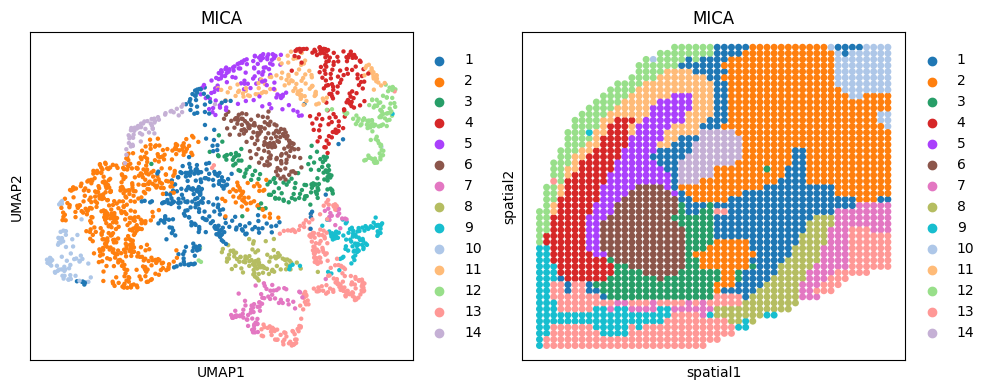

In [10]:
plot_results(adata_plot)